# 01 — Initial exploration

**Mock data only.** This notebook is for building/testing the pipeline
(DB → pandas → plots), not for drawing conclusions about vehicle
behavior — any correlations here are artifacts of the mock generator,
not real signal. Swapping in real data later should require no changes
below, just new rows underneath.

In [1]:
import sys, os

# diagnostic — confirm kernel/env are what we expect before doing anything else
print("Python executable:", sys.executable)
print("PYTHONPATH env var:", repr(os.environ.get("PYTHONPATH")))
print("ROS-looking paths in sys.path:", [p for p in sys.path if "ros" in p.lower()] or "none")

Python executable: /home/buvindu-suraweera/vehicle-telemetry-platform/analytics/.venv/bin/python
PYTHONPATH env var: None
ROS-looking paths in sys.path: none


In [2]:
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.db import query

sns.set_theme(style="darkgrid")

## Connection check

In [3]:
sessions = query("SELECT * FROM sessions ORDER BY started_at;")
sessions

,id,driver_id,started_at,ended_at,notes
0,mock_001,driver_a,2026-07-16 10:23:20.863447+00:00,None,Mock data session
1,live_001,driver_a,2026-07-16 10:23:20.866504+00:00,None,Live OBD session


## Pull raw telemetry

Adjust `session_id` below to whichever session the migrated mock data
actually landed under.

In [4]:
SESSION_ID = "mock_001"

df = query(
    "SELECT * FROM telemetry WHERE session_id = %(session_id)s ORDER BY time;",
    params={"session_id": SESSION_ID},
)
print(df.shape)
df.head()

(50353, 12)


,time,session_id,speed_kmh,rpm,throttle_pct,coolant_temp_c,engine_load_pct,accel_x,accel_y,accel_z,latitude,longitude
0,2026-06-29 13:47:27+00:00,mock_001,NaN,NaN,NaN,NaN,NaN,0.180,-0.180,11.065,None,None
1,2026-06-29 13:47:27+00:00,mock_001,NaN,NaN,NaN,NaN,NaN,0.184,-0.153,10.916,None,None
2,2026-06-29 13:47:27+00:00,mock_001,NaN,NaN,NaN,NaN,NaN,0.220,-0.084,11.010,None,None
3,2026-06-29 13:47:28+00:00,mock_001,NaN,NaN,NaN,NaN,NaN,0.228,-0.132,10.928,None,None
4,2026-06-29 13:47:28+00:00,mock_001,NaN,NaN,NaN,NaN,NaN,0.184,-0.163,10.873,None,None


In [5]:
df.describe()

,speed_kmh,rpm,throttle_pct,coolant_temp_c,engine_load_pct,accel_x,accel_y,accel_z
count,49740.000000,49740.000000,49740.000000,49740.000000,49740.000000,50353.000000,50353.000000,50353.000000
mean,60.035790,3401.359188,40.028947,84.994815,32.023179,0.089747,-0.063778,10.022298
std,21.175431,848.747317,14.467431,1.002962,11.574002,0.621989,0.395893,0.754787
min,30.000000,2053.000000,7.000000,80.300000,5.600000,-9.429000,-9.501000,-8.517000
25%,38.900000,2555.000000,26.300000,84.300000,21.000000,-0.141000,-0.175000,9.786000
50%,60.200000,3404.500000,40.100000,85.000000,32.100000,0.109000,-0.036000,9.828000
75%,81.100000,4246.000000,53.900000,85.700000,43.100000,0.287000,0.048000,9.897000
max,90.000000,4753.000000,70.800000,90.000000,56.700000,17.304000,9.573000,14.907000


## First-look plots

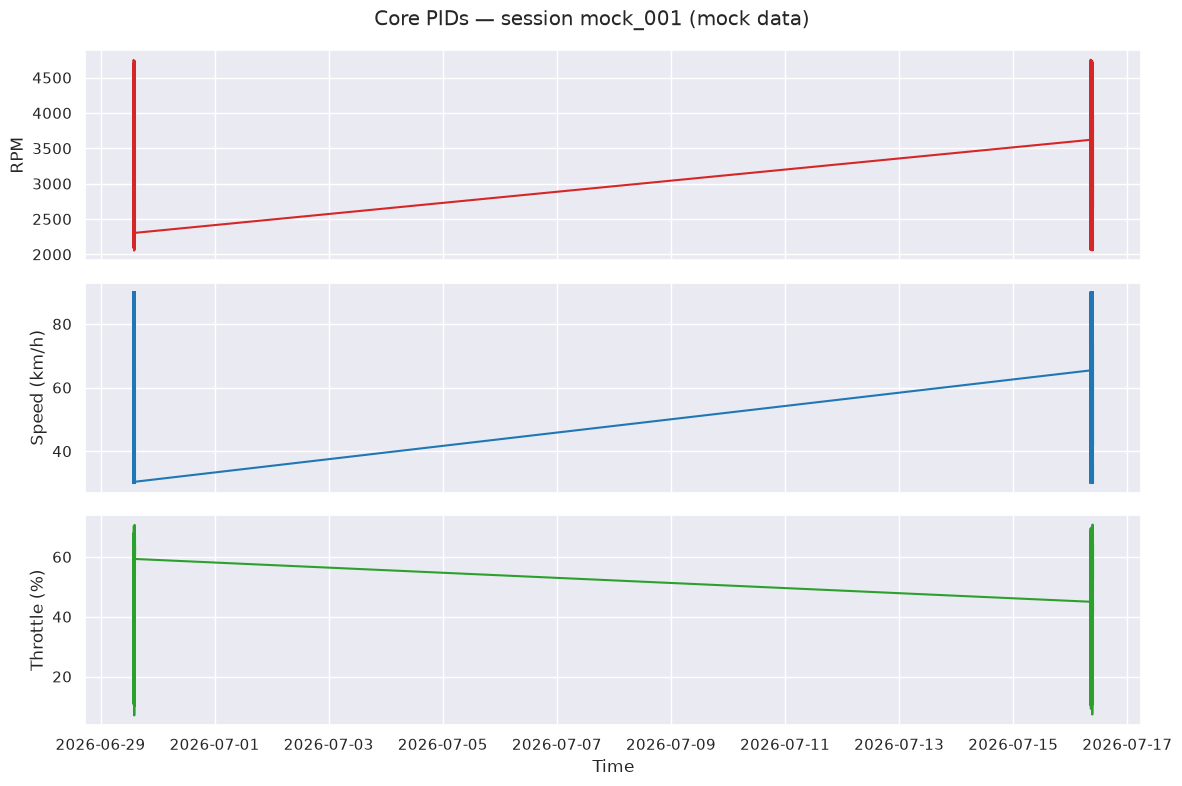

In [6]:
# Core PIDs over time — sanity check that the shapes look sane, not an
# analysis conclusion
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df["time"], df["rpm"], color="tab:red")
axes[0].set_ylabel("RPM")

axes[1].plot(df["time"], df["speed_kmh"], color="tab:blue")
axes[1].set_ylabel("Speed (km/h)")

axes[2].plot(df["time"], df["throttle_pct"], color="tab:green")
axes[2].set_ylabel("Throttle (%)")
axes[2].set_xlabel("Time")

fig.suptitle(f"Core PIDs — session {SESSION_ID} (mock data)")
fig.tight_layout()

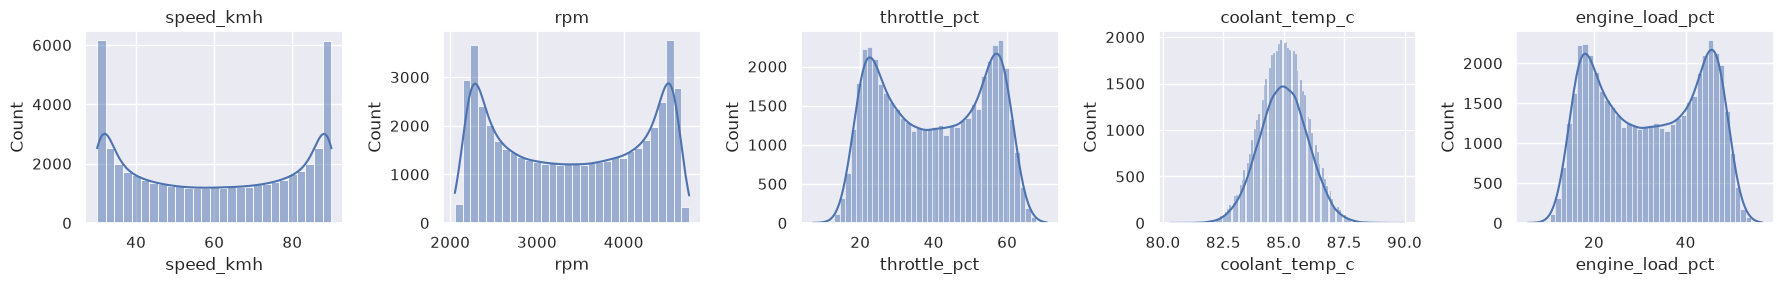

In [7]:
# Distributions — quick shape check across all core PIDs
core_pids = ["speed_kmh", "rpm", "throttle_pct", "coolant_temp_c", "engine_load_pct"]

fig, axes = plt.subplots(1, len(core_pids), figsize=(18, 3))
for ax, col in zip(axes, core_pids):
    sns.histplot(df[col].dropna(), ax=ax, kde=True)
    ax.set_title(col)
fig.tight_layout()

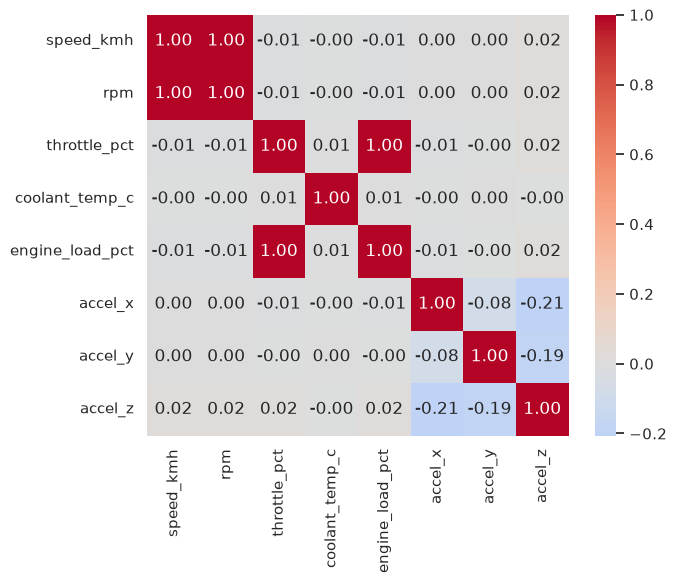

In [8]:
# Correlation matrix — pipeline check only. Do NOT read anything into
# these values while the data is synthetic — correlations here reflect
# the mock generator's own logic, not vehicle behavior.
corr = df[core_pids + ["accel_x", "accel_y", "accel_z"]].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
fig.tight_layout()